In [ ]:
"""
IPL Live Predictor v2
Replaces static Google Drive CSVs with live data from:
  - Cricsheet.org  → ball-by-ball + match info (full historical + current season)
  - ESPNcricinfo   → 2026 points table scrape (fallback: derived from Cricsheet)
"""

# install and import libraries
!pip install catboost lightgbm xgboost requests beautifulsoup4 lxml -q

import io
import os
import json
import shutil
import zipfile
import warnings
import requests

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bs4                    import BeautifulSoup
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import LabelEncoder
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics         import accuracy_score, roc_auc_score
from xgboost                 import XGBClassifier
from catboost                import CatBoostClassifier
from lightgbm                import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')
base = '/content/drive/MyDrive/IPL Predictor'
os.makedirs(base, exist_ok=True)

CACHE_DIR = '/content/ipl_data'
os.makedirs(CACHE_DIR, exist_ok=True)

# team data
team_colors = {
    'Punjab Kings':                '#ED1F24',
    'Royal Challengers Bengaluru': '#C8102E',
    'Sunrisers Hyderabad':         '#FF822A',
    'Rajasthan Royals':            '#EA1A85',
    'Gujarat Titans':              '#1C4E9D',
    'Chennai Super Kings':         '#F9CD05',
    'Delhi Capitals':              '#1D418A',
    'Kolkata Knight Riders':       '#3A225E',
    'Mumbai Indians':              '#004B87',
    'Lucknow Super Giants':        '#0057E7',
}

abbr_to_full = {
    'PBKS': 'Punjab Kings',
    'RCB':  'Royal Challengers Bengaluru',
    'SRH':  'Sunrisers Hyderabad',
    'RR':   'Rajasthan Royals',
    'GT':   'Gujarat Titans',
    'CSK':  'Chennai Super Kings',
    'DC':   'Delhi Capitals',
    'KKR':  'Kolkata Knight Riders',
    'MI':   'Mumbai Indians',
    'LSG':  'Lucknow Super Giants',
}
full_to_abbr = {v: k for k, v in abbr_to_full.items()}

old_names = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab':             'Punjab Kings',
    'Delhi Daredevils':            'Delhi Capitals',
    'Deccan Chargers':             'Sunrisers Hyderabad',
    'Gujarat Lions':               'Gujarat Titans',
    'Rising Pune Supergiant':      'Chennai Super Kings',
    'Rising Pune Supergiants':     'Chennai Super Kings',
    'Pune Warriors':               'Chennai Super Kings',
    'Kochi Tuskers Kerala':        'Mumbai Indians',
    'Kolkata Night Riders':        'Kolkata Knight Riders',
}

current_teams = list(abbr_to_full.values())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


#Source: Cricsheet.org — free, no auth, updated after each match
#URL:    https://cricsheet.org/downloads/ipl_csv2.zip
#Contains every IPL match as a pair of CSV files:
#<match_id>_info.csv  — match metadata (teams, venue, winner …)
#<match_id>.csv       — ball-by-ball deliveries


In [ ]:
CRICSHEET_URL = 'https://cricsheet.org/downloads/ipl_csv2.zip'
ZIP_PATH      = os.path.join(CACHE_DIR, 'ipl_csv2.zip')
EXTRACT_DIR   = os.path.join(CACHE_DIR, 'ipl_csv2')


def download_cricsheet(force_refresh: bool = False) -> None:
    """
    downloads the Cricsheet IPL CSV pack
    set force_refresh=True to re-download even if a cached copy exists
    the zip is ~50 MB and includes every IPL match up to the most recent
    one that Cricsheet has processed (usually within 24 hrs after the match)
    """
    if os.path.exists(ZIP_PATH) and not force_refresh:
        print('using cached Cricsheet data (set force_refresh=True to update)')
        return

    print('downloading live IPL data from Cricsheet …')
    resp = requests.get(CRICSHEET_URL, stream=True, timeout=120)
    resp.raise_for_status()

    total = int(resp.headers.get('content-length', 0))
    downloaded = 0
    with open(ZIP_PATH, 'wb') as fh:
        for chunk in resp.iter_content(chunk_size=65536):
            fh.write(chunk)
            downloaded += len(chunk)
            if total:
                pct = downloaded / total * 100
                print(f'\r   {pct:.1f}%', end='', flush=True)



def extract_cricsheet() -> None:
    """unpack the zip if not already done."""
    if os.path.exists(EXTRACT_DIR) and len(os.listdir(EXTRACT_DIR)) > 10:
        return
    print('📂 Extracting …')
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print(f'extracted {len(os.listdir(EXTRACT_DIR))} files')


download_cricsheet(force_refresh=False)   # change to True to always fetch fresh
extract_cricsheet()


def load_cricsheet_matches() -> pd.DataFrame:
    """
    parse every *_info.csv file in the Cricsheet extract into a single
    dataFrame whose columns mirror what the original Colab expected:
        id, team1, team2, winner, toss_winner, toss_decision, venue, season, date
    """
    rows = []
    info_files = sorted(f for f in os.listdir(EXTRACT_DIR) if f.endswith('_info.csv'))
    print(f'parsing {len(info_files)} match info files …')

    for fname in info_files:
        path = os.path.join(EXTRACT_DIR, fname)
        try:
            df = pd.read_csv(path, header=None, names=['type', 'key', 'value'],
                             dtype=str, on_bad_lines='skip')
            info = df.set_index('key')['value'].to_dict()

            # cricsheet info files are key→value rows
            # multiple rows share the same key (e.g. two 'team' rows)
            multi = {}
            for _, row in df.iterrows():
                multi.setdefault(row['key'], []).append(row['value'])

            teams = multi.get('team', [])
            if len(teams) < 2:
                continue

            rows.append({
                'id':            fname.replace('_info.csv', ''),
                'team1':         teams[0],
                'team2':         teams[1],
                'winner':        info.get('winner', np.nan),
                'toss_winner':   info.get('toss_winner', np.nan),
                'toss_decision': info.get('toss_decision', np.nan),
                'venue':         info.get('venue', np.nan),
                'season':        info.get('season', np.nan),
                'date':          info.get('date', np.nan),
                'result':        info.get('result', 'normal'),
            })
        except Exception:
            continue

    matches = pd.DataFrame(rows)
    print(f'loaded {len(matches)} IPL matches from Cricsheet')
    return matches


def load_cricsheet_deliveries() -> pd.DataFrame:
    """
    load ball-by-ball data for the current season (most recent year in
    the dataset) so we can compute batting/bowling stats for 2026.
    Only reads non-info CSV files (i.e., the delivery files).
    """
    delivery_files = sorted(
        f for f in os.listdir(EXTRACT_DIR)
        if f.endswith('.csv') and not f.endswith('_info.csv')
    )

    # determine the current season from match data
    info_files = sorted(f for f in os.listdir(EXTRACT_DIR) if f.endswith('_info.csv'))
    seasons = []
    for fname in info_files[:50]:   # sample the first 50 to find max season
        path = os.path.join(EXTRACT_DIR, fname)
        try:
            df = pd.read_csv(path, header=None, names=['type','key','value'],
                             dtype=str, on_bad_lines='skip')
            info = df.set_index('key')['value'].to_dict()
            if 'season' in info:
                seasons.append(str(info['season']))
        except Exception:
            continue

    # also scan the rest to find the true max season
    for fname in info_files:
        path = os.path.join(EXTRACT_DIR, fname)
        try:
            df = pd.read_csv(path, header=None, names=['type','key','value'],
                             dtype=str, on_bad_lines='skip')
            info = df.set_index('key')['value'].to_dict()
            if 'season' in info:
                seasons.append(str(info['season']))
        except Exception:
            continue

    current_season = max(set(seasons), key=lambda s: s) if seasons else '2026'
    print(f'current season detected: {current_season}')

    # find match IDs for the current season
    current_ids = set()
    for fname in info_files:
        path = os.path.join(EXTRACT_DIR, fname)
        try:
            df = pd.read_csv(path, header=None, names=['type','key','value'],
                             dtype=str, on_bad_lines='skip')
            info = df.set_index('key')['value'].to_dict()
            if str(info.get('season', '')) == current_season:
                current_ids.add(fname.replace('_info.csv', ''))
        except Exception:
            continue

    print(f'loading deliveries for {len(current_ids)} matches in {current_season} …')

    dfs = []
    for fid in current_ids:
        path = os.path.join(EXTRACT_DIR, f'{fid}.csv')
        if os.path.exists(path):
            try:
                dfs.append(pd.read_csv(path, dtype=str, on_bad_lines='skip'))
            except Exception:
                continue

    if not dfs:
        print('no delivery files found for current season')
        return pd.DataFrame()

    deliveries = pd.concat(dfs, ignore_index=True)
    print(f'loaded {len(deliveries):,} deliveries for {current_season}')
    return deliveries, current_season


# load everything
all_matches = load_cricsheet_matches()
deliveries_raw, CURRENT_SEASON = load_cricsheet_deliveries()


# clean team names (same logic as original)
def clean_team_names(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    for col in cols:
        if col in df.columns:
            df[col] = df[col].replace(old_names)
    return df

all_matches = clean_team_names(all_matches,
                               ['team1', 'team2', 'winner', 'toss_winner'])

# keep only current 10 teams
hist_matches = all_matches[
    all_matches['team1'].isin(current_teams) &
    all_matches['team2'].isin(current_teams)
].copy()

# drop matches where there was no result
hist_matches = hist_matches[hist_matches['result'] != 'no result'].copy()
hist_matches = hist_matches.dropna(subset=['winner', 'toss_winner', 'toss_decision'])

# split into before 2026 and 2026
matches_hist   = hist_matches[hist_matches['season'] != CURRENT_SEASON].copy()
matches_2026   = hist_matches[hist_matches['season'] == CURRENT_SEASON].copy()

print(f'Historical matches (excl. {CURRENT_SEASON}): {len(matches_hist)}')
print(f'{CURRENT_SEASON} matches so far: {len(matches_2026)}')


using cached Cricsheet data (set force_refresh=True to update)
parsing 1241 match info files …
loaded 1241 IPL matches from Cricsheet
current season detected: 2026
loading deliveries for 72 matches in 2026 …
loaded 17,053 deliveries for 2026
Historical matches (excl. 2026): 1146
2026 matches so far: 70


In [ ]:

#replace the static points_table.csv, batting_stats.csv, bowling_stats.csv from v1


In [ ]:
def build_points_table(matches_2026: pd.DataFrame, deliveries_raw: pd.DataFrame) -> pd.DataFrame:
    """Reconstruct points table from match results."""
    records = []

    # Pre-calculate NRR components for each team
    team_nrr_data = {}
    for team in current_teams:
        team_deliveries_batting = deliveries_raw[deliveries_raw['batting_team'] == team].copy()
        team_deliveries_bowling = deliveries_raw[deliveries_raw['bowling_team'] == team].copy()

        # Runs scored and balls faced (when batting)
        runs_scored = (
            pd.to_numeric(team_deliveries_batting.get('runs_off_bat', 0), errors='coerce').fillna(0) +
            pd.to_numeric(team_deliveries_batting.get('extras', 0), errors='coerce').fillna(0)
        ).sum()

        # Balls faced: exclude wides as they are not "legal" deliveries for NRR calculation
        balls_faced = team_deliveries_batting[pd.to_numeric(team_deliveries_batting.get('wides', 0), errors='coerce').fillna(0) == 0].shape[0]

        # Runs conceded and balls bowled (when bowling)
        runs_conceded = (
            pd.to_numeric(team_deliveries_bowling.get('runs_off_bat', 0), errors='coerce').fillna(0) +
            pd.to_numeric(team_deliveries_bowling.get('extras', 0), errors='coerce').fillna(0)
        ).sum()

        # Balls bowled: exclude wides and noballs as they are not "legal" deliveries
        balls_bowled = team_deliveries_bowling[(pd.to_numeric(team_deliveries_bowling.get('wides', 0), errors='coerce').fillna(0) == 0) & (pd.to_numeric(team_deliveries_bowling.get('noballs', 0), errors='coerce').fillna(0) == 0)].shape[0]

        overs_faced  = balls_faced / 6 if balls_faced > 0 else 0
        overs_bowled = balls_bowled / 6 if balls_bowled > 0 else 0

        team_nrr_data[team] = {
            'runs_scored': runs_scored,
            'overs_faced': overs_faced,
            'runs_conceded': runs_conceded,
            'overs_bowled': overs_bowled
        }

    for team in current_teams:
        played = matches_2026[
            (matches_2026['team1'] == team) | (matches_2026['team2'] == team)
        ]
        wins    = (played['winner'] == team).sum()
        matches = len(played)
        losses  = matches - wins

        # Calculate NRR
        nrr_value = 0.0
        if team in team_nrr_data:
            data = team_nrr_data[team]
            if data['overs_faced'] > 0 and data['overs_bowled'] > 0:
                nrr_value = (data['runs_scored'] / data['overs_faced']) - \
                            (data['runs_conceded'] / data['overs_bowled'])
            # Edge cases for NRR where a team might have only batted or only bowled (unlikely in full season)
            elif data['overs_faced'] > 0:
                nrr_value = data['runs_scored'] / data['overs_faced']
            elif data['overs_bowled'] > 0:
                nrr_value = - (data['runs_conceded'] / data['overs_bowled'])

        records.append({
            'team':    team,
            'matches': matches,
            'wins':    wins,
            'defeats': losses,
            'points':  wins * 2,
            'nrr':     round(nrr_value, 3),  # NRR requires runs; filled below if deliveries available
        })
    pt = pd.DataFrame(records).sort_values('points', ascending=False).reset_index(drop=True)
    return pt


def build_batting_stats(deliveries: pd.DataFrame,
                        team_col: str = 'batting_team') -> pd.DataFrame:
    """Aggregate per-batter stats from Cricsheet delivery data."""
    if deliveries.empty:
        return pd.DataFrame(columns=['batsman','team','runs','balls','strike_rate','average'])

    # Cricsheet CSV2 columns: match_id, innings, ball, batting_team, bowling_team,
    #                          striker, non_striker, bowler, runs_off_bat,
    #                          extras, wides, noballs, byes, legbyes, penalty,
    #                          wicket_type, player_dismissed, other_wicket_type, ...
    d = deliveries.copy()
    d['runs_off_bat'] = pd.to_numeric(d.get('runs_off_bat', 0), errors='coerce').fillna(0)
    d['wides']        = pd.to_numeric(d.get('wides', 0),        errors='coerce').fillna(0)

    # A legal delivery faced by the batter (not a wide)
    d['ball_faced'] = (d['wides'] == 0).astype(int)
    d['is_out']     = d.get('wicket_type', '').notna() & (d.get('wicket_type', '') != '')

    # Rename to normalise
    team_col_actual = team_col if team_col in d.columns else 'batting_team'

    grp = d.groupby(['striker', team_col_actual])
    stats = grp.agg(
        runs   = ('runs_off_bat', 'sum'),
        balls  = ('ball_faced',   'sum'),
        outs   = ('is_out',       'sum'),
    ).reset_index()
    stats.columns = ['batsman', 'team', 'runs', 'balls', 'outs']
    stats['strike_rate'] = (stats['runs'] / stats['balls'].replace(0, np.nan) * 100).round(2)
    stats['average']     = (stats['runs'] / stats['outs'].replace(0, np.nan)).round(2)

    # Map old team names
    stats['team'] = stats['team'].replace(old_names)
    stats = stats[stats['team'].isin(current_teams)]
    return stats.fillna(0)


def build_bowling_stats(deliveries: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-bowler stats from Cricsheet delivery data."""
    if deliveries.empty:
        return pd.DataFrame(columns=['bowler','team','wickets','runs','overs','economy'])

    d = deliveries.copy()
    d['runs_off_bat'] = pd.to_numeric(d.get('runs_off_bat', 0), errors='coerce').fillna(0)
    d['extras']       = pd.to_numeric(d.get('extras',       0), errors='coerce').fillna(0)
    d['wides']        = pd.to_numeric(d.get('wides',        0), errors='coerce').fillna(0)
    d['noballs']      = pd.to_numeric(d.get('noballs',      0), errors='coerce').fillna(0)

    d['runs_conceded'] = d['runs_off_bat'] + d['extras']
    d['legal_ball']    = ((d['wides'] == 0) & (d['noballs'] == 0)).astype(int)
    d['is_wicket']     = (
        d.get('wicket_type', pd.Series([''] * len(d))).notna() &
        (d.get('wicket_type', pd.Series([''] * len(d))) != '') &
        (~d.get('wicket_type', pd.Series([''] * len(d))).isin(['run out']))
    )

    bowling_team_col = 'bowling_team' if 'bowling_team' in d.columns else None

    if bowling_team_col:
        grp = d.groupby(['bowler', bowling_team_col])
    else:
        grp = d.groupby('bowler')

    stats = grp.agg(
        wickets = ('is_wicket',      'sum'),
        runs    = ('runs_conceded',  'sum'),
        balls   = ('legal_ball',     'sum'),
    ).reset_index()

    if bowling_team_col:
        stats.columns = ['bowler', 'team', 'wickets', 'runs', 'balls']
    else:
        stats.columns = ['bowler', 'wickets', 'runs', 'balls']
        stats['team'] = 'Unknown'

    stats['overs']   = (stats['balls'] / 6).round(1)
    stats['economy'] = (stats['runs'] / stats['overs'].replace(0, np.nan)).round(2)

    stats['team'] = stats['team'].replace(old_names)
    stats = stats[stats['team'].isin(current_teams)]
    return stats.fillna(0)


# Build live stats
points_table  = build_points_table(matches_2026, deliveries_raw)
batting_stats = build_batting_stats(deliveries_raw)
bowling_stats = build_bowling_stats(deliveries_raw)

print('\n📊 Points table (live):')
print(points_table[['team','matches','wins','defeats','points']].to_string(index=False))
print(f'\nBatters tracked: {len(batting_stats)}')
print(f'Bowlers tracked: {len(bowling_stats)}')


📊 Points table (live):
                       team  matches  wins  defeats  points
Royal Challengers Bengaluru       15    10        5      20
        Sunrisers Hyderabad       15     9        6      18
             Gujarat Titans       15     9        6      18
           Rajasthan Royals       15     9        6      18
               Punjab Kings       13     7        6      14
             Delhi Capitals       14     7        7      14
        Chennai Super Kings       14     6        8      12
      Kolkata Knight Riders       12     5        7      10
             Mumbai Indians       14     4       10       8
       Lucknow Super Giants       13     4        9       8

Batters tracked: 176
Bowlers tracked: 125


In [ ]:

# visualizations identical to v1 but data sources differ

In [ ]:
standings = points_table.sort_values('points', ascending=False).reset_index(drop=True)

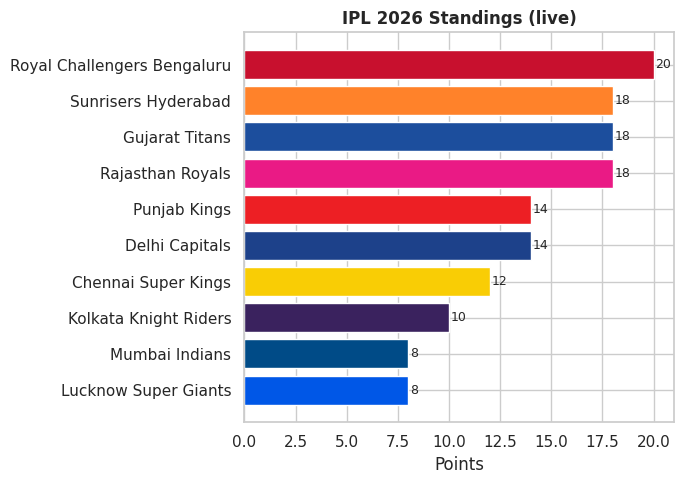

In [ ]:
# --- points table ---
fig, ax = plt.subplots(figsize=(7, 5))
colors = [team_colors.get(t, '#aaa') for t in standings['team']]
ax.barh(standings['team'][::-1], standings['points'][::-1], color=colors[::-1])
ax.set_xlabel('Points')
ax.set_title(f'IPL {CURRENT_SEASON} Standings (live)', fontweight='bold')
for i, pts in enumerate(standings['points'][::-1]):
    ax.text(pts + 0.1, i, str(pts), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/viz_standings_points.png', bbox_inches='tight')
plt.show()

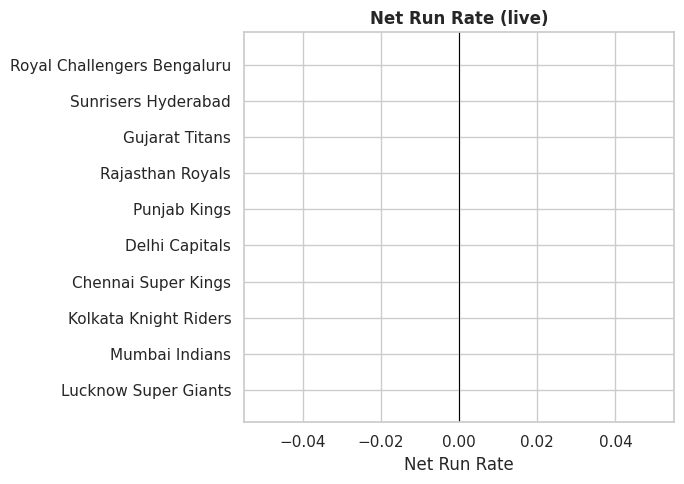

In [ ]:
# --- NRR bar (0 for all if deliveries incomplete) ---
fig, ax = plt.subplots(figsize=(7, 5))
nrr_colors = ['#27ae60' if n >= 0 else '#e74c3c' for n in standings['nrr'][::-1]]
ax.barh(standings['team'][::-1], standings['nrr'][::-1], color=nrr_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Net Run Rate')
ax.set_title('Net Run Rate (live)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/viz_standings_nrr.png', bbox_inches='tight')
plt.show()

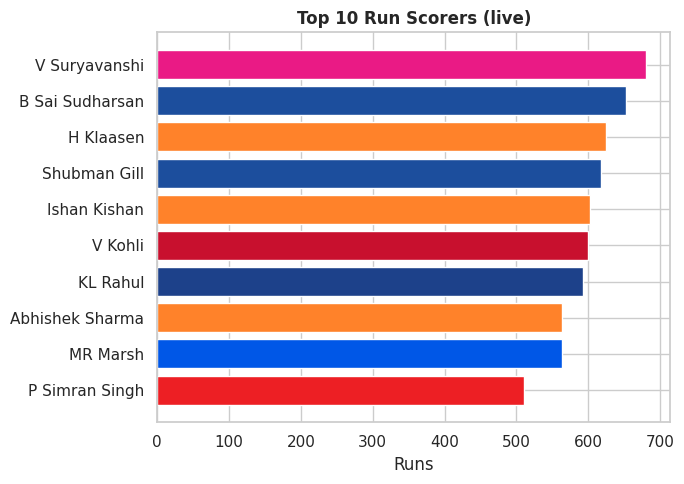

In [ ]:
# --- top batters ---
if not batting_stats.empty:
    top_batters = batting_stats.sort_values('runs', ascending=False).head(10)
    bat_colors  = [team_colors.get(t, '#aaa') for t in top_batters['team']]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(top_batters['batsman'][::-1], top_batters['runs'][::-1], color=bat_colors[::-1])
    ax.set_xlabel('Runs')
    ax.set_title('Top 10 Run Scorers (live)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/viz_top_batters.png', bbox_inches='tight')
    plt.show()

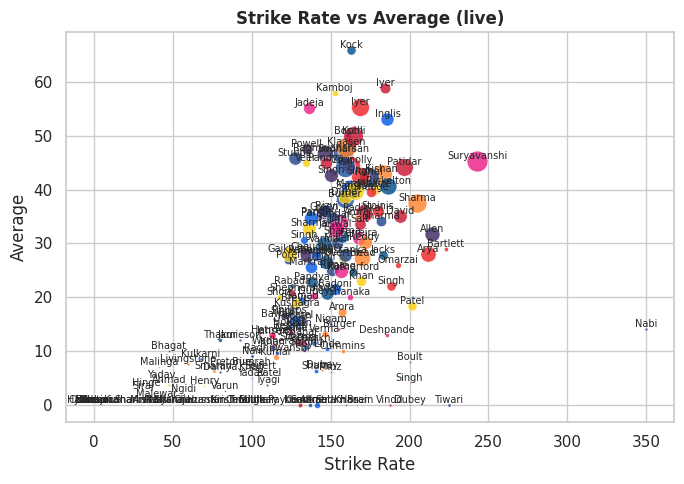

In [ ]:
# --- strike rate vs average ---
if not batting_stats.empty:
    fig, ax = plt.subplots(figsize=(7, 5))
    for _, row in batting_stats.iterrows():
        c = team_colors.get(row['team'], '#aaa')
        ax.scatter(row['strike_rate'], row['average'],
                   s=row['runs'] / 3, color=c, alpha=0.8,
                   edgecolors='white', linewidth=0.5)
        ax.annotate(str(row['batsman']).split()[-1],
                    (row['strike_rate'], row['average']),
                    fontsize=7, ha='center', va='bottom')
    ax.set_xlabel('Strike Rate')
    ax.set_ylabel('Average')
    ax.set_title('Strike Rate vs Average (live)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/viz_sr_avg.png', bbox_inches='tight')
    plt.show()

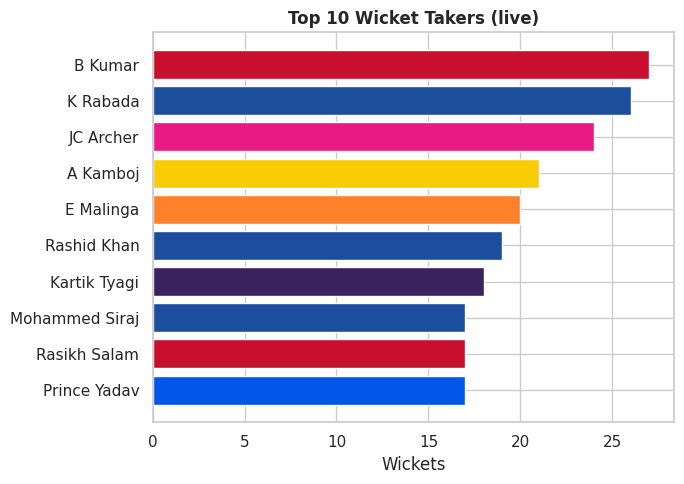

In [ ]:
# --- Top bowlers ---
if not bowling_stats.empty:
    top_bowlers = bowling_stats.sort_values('wickets', ascending=False).head(10)
    bowl_colors = [team_colors.get(t, '#aaa') for t in top_bowlers['team']]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(top_bowlers['bowler'][::-1], top_bowlers['wickets'][::-1], color=bowl_colors[::-1])
    ax.set_xlabel('Wickets')
    ax.set_title('Top 10 Wicket Takers (live)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/viz_top_bowlers.png', bbox_inches='tight')
    plt.show()

In [ ]:

# find venue bias from historical Cricsheet data same calculation as done in v1


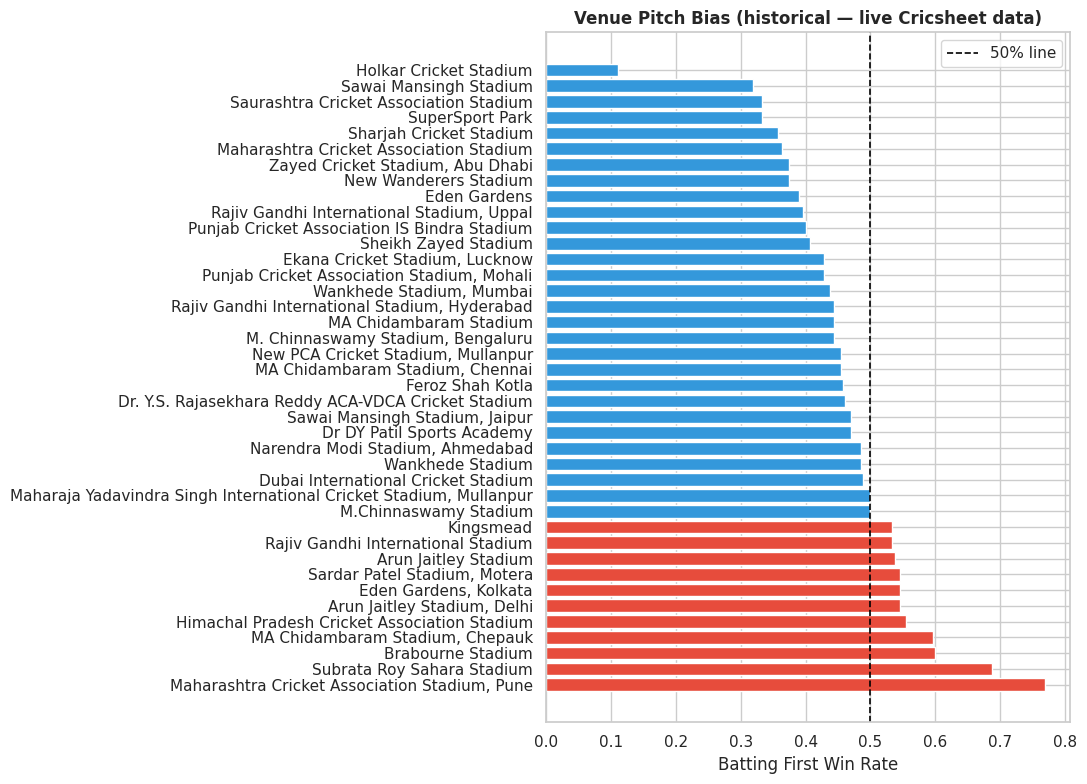

Venue data for 40 grounds


In [ ]:
venue_fixes = {
    'M Chinnaswamy Stadium, Bengaluru':  'M. Chinnaswamy Stadium, Bengaluru',
    'M Chinnaswamy Stadium':             'M. Chinnaswamy Stadium, Bengaluru',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad':
                                         'Rajiv Gandhi International Stadium, Hyderabad',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium, Chennai',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow':
                                         'Ekana Cricket Stadium, Lucknow',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala':
                                         'HPCA Stadium, Dharamshala',
    'Punjab Cricket Association IS Bindra Stadium, Mohali':
                                         'New PCA Cricket Stadium, Mullanpur',
    'Dr DY Patil Sports Academy, Mumbai':'Wankhede Stadium, Mumbai',
    'Brabourne Stadium, Mumbai':         'Wankhede Stadium, Mumbai',
}

matches_hist['venue'] = matches_hist['venue'].replace(venue_fixes)
matches_hist['bat_first_won'] = (
    ((matches_hist['toss_decision'] == 'bat')   & (matches_hist['toss_winner'] == matches_hist['winner'])) |
    ((matches_hist['toss_decision'] == 'field') & (matches_hist['toss_winner'] != matches_hist['winner']))
)

venue_stats = matches_hist.groupby('venue').agg(
    total        = ('id', 'count'),
    bat_first_wins = ('bat_first_won', 'sum')
).reset_index()
venue_stats = venue_stats[venue_stats['total'] >= 8]
venue_stats['bat_first_win_rate'] = venue_stats['bat_first_wins'] / venue_stats['total']
venue_stats = venue_stats.sort_values('bat_first_win_rate', ascending=False)

plt.figure(figsize=(11, 8))
bar_colors = ['#e74c3c' if r > 0.5 else '#3498db' for r in venue_stats['bat_first_win_rate']]
plt.barh(venue_stats['venue'], venue_stats['bat_first_win_rate'], color=bar_colors)
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% line')
plt.xlabel('Batting First Win Rate')
plt.title('Venue Pitch Bias (historical — live Cricsheet data)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('/content/viz_venue.png', bbox_inches='tight')
plt.show()

venue_bias = dict(zip(venue_stats['venue'], venue_stats['bat_first_win_rate']))
print(f'Venue data for {len(venue_bias)} grounds')


In [ ]:
# team strength calculated using same composite formula as original version


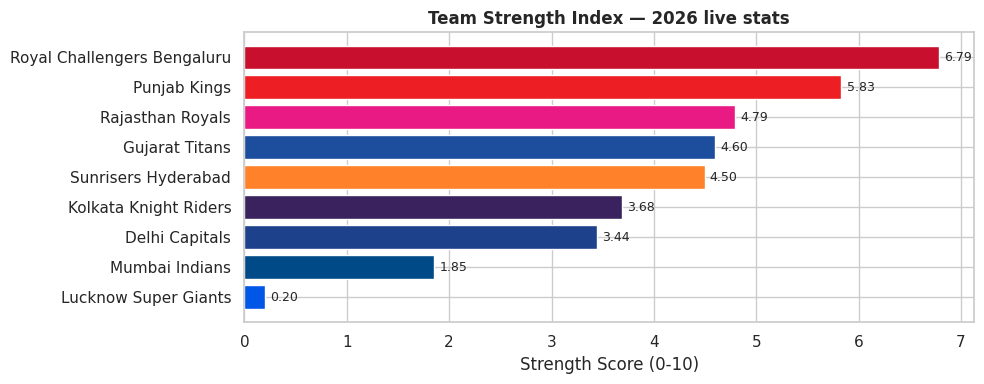

In [ ]:
pt = points_table.copy()
pt['win_rate'] = pt['wins'] / pt['matches'].replace(0, np.nan)

bat_by_team  = batting_stats.groupby('team').agg(
    avg_sr  = ('strike_rate', 'mean'),
    avg_avg = ('average',     'mean')
).reset_index() if not batting_stats.empty else pd.DataFrame(columns=['team','avg_sr','avg_avg'])

bowl_by_team = bowling_stats.groupby('team').agg(
    avg_econ = ('economy', 'mean')
).reset_index() if not bowling_stats.empty else pd.DataFrame(columns=['team','avg_econ'])

strength = pt[['team', 'win_rate', 'nrr']].copy()
strength = strength.merge(bat_by_team,  on='team', how='left')
strength = strength.merge(bowl_by_team, on='team', how='left')
strength = strength[strength['team'] != 'Chennai Super Kings'].copy()

# Fill missing with column mean
for col in ['avg_sr', 'avg_avg', 'avg_econ']:
    strength[col] = strength[col].fillna(strength[col].mean())
strength['win_rate'] = strength['win_rate'].fillna(0.5)

def normalize(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 0.0001)

strength['score'] = (
    0.35 * normalize(strength['win_rate']) +
    0.20 * normalize(strength['nrr']) +
    0.20 * normalize(strength['avg_sr']) +
    0.15 * normalize(strength['avg_avg']) +
    0.10 * (1 - normalize(strength['avg_econ']))
) * 10

team_strength = dict(zip(strength['team'], strength['score']))
nrr_map       = dict(zip(points_table['team'], points_table['nrr']))

s_sorted = strength.sort_values('score', ascending=False)
plt.figure(figsize=(10, 4))
bar_colors = [team_colors.get(t, '#aaa') for t in s_sorted['team'][::-1]]
plt.barh(s_sorted['team'][::-1], s_sorted['score'][::-1], color=bar_colors)
plt.xlabel('Strength Score (0-10)')
plt.title(f'Team Strength Index — {CURRENT_SEASON} live stats', fontweight='bold')
for i, sc in enumerate(s_sorted['score'][::-1]):
    plt.text(sc + 0.05, i, f'{sc:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/viz_strength.png', bbox_inches='tight')
plt.show()


## 🤝 8. Head-to-Head Records

In [ ]:
# 8. head-to-head using full Cricsheet history


In [ ]:
h2h = {}
for team_a in current_teams:
    for team_b in current_teams:
        if team_a == team_b:
            continue
        games = hist_matches[
            ((hist_matches['team1'] == team_a) & (hist_matches['team2'] == team_b)) |
            ((hist_matches['team1'] == team_b) & (hist_matches['team2'] == team_a))
        ]
        h2h[(team_a, team_b)] = (games['winner'] == team_a).sum() / len(games) if len(games) else 0.5

print(f'h2h records calculated for {len(h2h)} matchups')


h2h records calculated for 90 matchups


In [ ]:

# feature engineering and model training unchanged from original


Training samples: 972  |  test: 244
Logistic Regression        acc=0.615  AUC=0.613  CV=0.571
Random Forest              acc=0.516  AUC=0.505  CV=0.511
Gradient Boosting          acc=0.533  AUC=0.539  CV=0.502
XGBoost                    acc=0.504  AUC=0.513  CV=0.496
CatBoost                   acc=0.525  AUC=0.547  CV=0.512
LightGBM                   acc=0.488  AUC=0.508  CV=0.494

 Best model: Logistic Regression


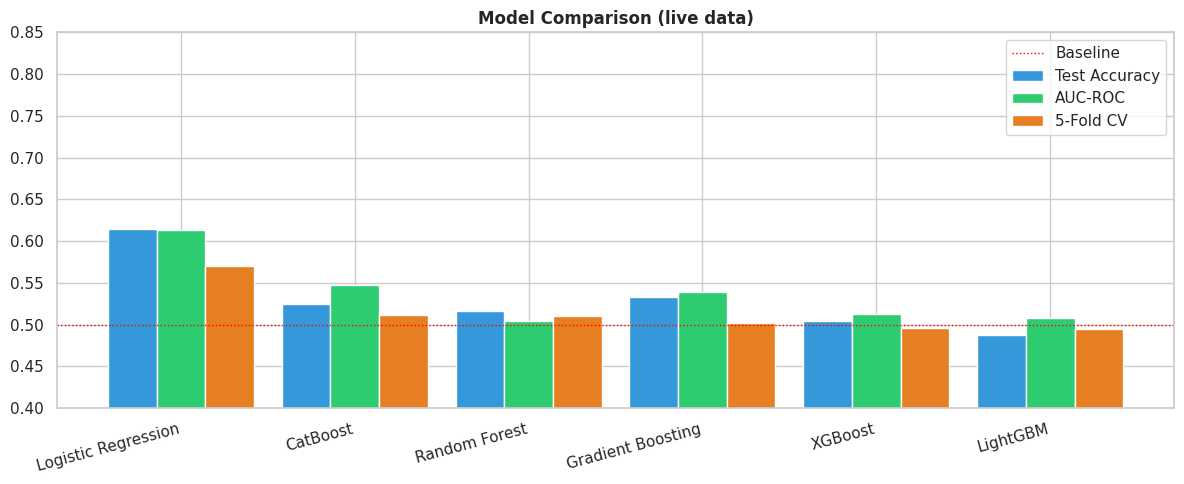

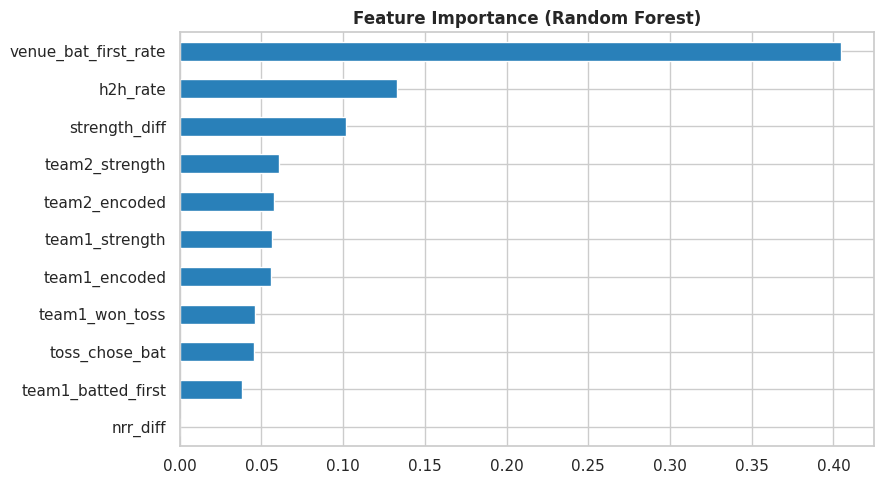

In [ ]:
df = hist_matches.copy()
df['team1_win']          = (df['team1'] == df['winner']).astype(int)
df['team1_won_toss']     = (df['team1'] == df['toss_winner']).astype(int)
df['toss_chose_bat']     = (df['toss_decision'] == 'bat').astype(int)
df['team1_batted_first'] = (
    ((df['team1_won_toss'] == 1) & (df['toss_chose_bat'] == 1)) |
    ((df['team1_won_toss'] == 0) & (df['toss_chose_bat'] == 0))
).astype(int)
df['venue']              = df['venue'].replace(venue_fixes)
df['venue_bat_first_rate'] = df['venue'].map(venue_bias).fillna(0.5)
df['team1_strength']     = df['team1'].map(team_strength).fillna(5.0)
df['team2_strength']     = df['team2'].map(team_strength).fillna(5.0)
df['strength_diff']      = df['team1_strength'] - df['team2_strength']
df['h2h_rate']           = df.apply(lambda r: h2h.get((r['team1'], r['team2']), 0.5), axis=1)
df['nrr_diff']           = df['team1'].map(nrr_map).fillna(0) - df['team2'].map(nrr_map).fillna(0)

encoder  = LabelEncoder()
encoder.fit(list(df['team1'].values) + list(df['team2'].values))
df['team1_encoded'] = encoder.transform(df['team1'])
df['team2_encoded'] = encoder.transform(df['team2'])

feature_cols = [
    'team1_encoded', 'team2_encoded',
    'team1_won_toss', 'toss_chose_bat', 'team1_batted_first',
    'venue_bat_first_rate',
    'team1_strength', 'team2_strength', 'strength_diff',
    'h2h_rate', 'nrr_diff'
]

X, y = df[feature_cols], df['team1_win']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)
print(f'Training samples: {len(X_train)}  |  test: {len(X_test)}')

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42),
    'CatBoost':            CatBoostClassifier(iterations=200, verbose=0, random_state=42),
    'LightGBM':            LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    cv  = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    results[name] = {'accuracy': acc, 'auc': auc, 'cv_accuracy': cv}
    print(f'{name:<25}  acc={acc:.3f}  AUC={auc:.3f}  CV={cv:.3f}')

best_model_name = max(results, key=lambda k: results[k]['cv_accuracy'])
print(f'\n Best model: {best_model_name}')

# model comparison chart
res_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
res_df = res_df.sort_values('cv_accuracy', ascending=False)
x, w = np.arange(len(res_df)), 0.28
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, res_df['accuracy'],    w, label='Test Accuracy', color='#3498db')
ax.bar(x,     res_df['auc'],         w, label='AUC-ROC',       color='#2ecc71')
ax.bar(x + w, res_df['cv_accuracy'], w, label='5-Fold CV',     color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(res_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.4, 0.85)
ax.set_title('Model Comparison (live data)', fontweight='bold')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1, label='Baseline')
ax.legend()
plt.tight_layout()
plt.savefig('/content/viz_models.png', bbox_inches='tight')
plt.show()

# feature importance
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='#2980b9')
plt.title('Feature Importance (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/viz_features.png', bbox_inches='tight')
plt.show()


In [ ]:

# 10. prediction engine (same as v1)


In [ ]:
model_weights = {
    'Logistic Regression': 1,
    'Random Forest':       2,
    'Gradient Boosting':   2,
    'XGBoost':             3,
    'CatBoost':            3,
    'LightGBM':            2
}

def predict_match(team_a, team_b, venue, team_a_toss=True, toss_bat=False):
    """return ensemble win probability for team_a vs team_b."""
    try:
        enc_a = encoder.transform([team_a])[0]
        enc_b = encoder.transform([team_b])[0]
    except Exception:
        print('team name not recognised — check spelling.')
        return 0.5, {}

    pitch     = venue_bias.get(venue, 0.5)
    toss_win  = int(team_a_toss)
    chose_bat = int(toss_bat)
    bat_first = int((team_a_toss and toss_bat) or (not team_a_toss and not toss_bat))
    str_a     = team_strength.get(team_a, 5.0)
    str_b     = team_strength.get(team_b, 5.0)
    nrr_a     = nrr_map.get(team_a, 0.0)
    nrr_b     = nrr_map.get(team_b, 0.0)
    h2h_r     = h2h.get((team_a, team_b), 0.5)

    row = pd.DataFrame([[
        enc_a, enc_b, toss_win, chose_bat, bat_first,
        pitch, str_a, str_b, str_a - str_b, h2h_r, nrr_a - nrr_b
    ]], columns=feature_cols)

    model_probs = {n: m.predict_proba(row)[0][1] for n, m in models.items()}
    weighted    = sum(model_probs[n] * model_weights[n] for n in model_weights)
    final_prob  = max(0.05, min(0.95, weighted / sum(model_weights.values())))
    return final_prob, model_probs


def show_prediction(team_a, team_b, venue, team_a_toss=True, toss_bat=False):
    prob, model_probs = predict_match(team_a, team_b, venue, team_a_toss, toss_bat)
    abbr_a   = full_to_abbr.get(team_a, team_a)
    abbr_b   = full_to_abbr.get(team_b, team_b)
    color_a  = team_colors.get(team_a, '#3498db')
    color_b  = team_colors.get(team_b, '#e74c3c')
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].barh([abbr_b, abbr_a], [1 - prob, prob], color=[color_b, color_a])
    axes[0].axvline(0.5, color='black', linestyle='--')
    axes[0].set_xlim(0, 1)
    axes[0].set_xlabel('Win Probability')
    axes[0].set_title(f'{abbr_a} vs {abbr_b}', fontweight='bold', fontsize=13)
    axes[0].text(prob - 0.02, 1, f'{prob:.0%}',
                 va='center', ha='right', color='white', fontweight='bold', fontsize=12)
    axes[0].text((1 - prob) - 0.02, 0, f'{1 - prob:.0%}',
                 va='center', ha='right', color='white', fontweight='bold', fontsize=12)
    names = list(model_probs.keys())
    vals  = list(model_probs.values())
    axes[1].plot(names, vals, 'o-', color='#2c3e50', linewidth=2)
    axes[1].axhline(prob, color='#27ae60', linestyle='--', linewidth=1.5,
                    label=f'Ensemble: {prob:.1%}')
    axes[1].axhline(0.5, color='red', linestyle=':', linewidth=1, label='50/50')
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel(f'{abbr_a} win probability')
    axes[1].set_title('How each model voted', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'/content/pred_{abbr_a}_vs_{abbr_b}.png', bbox_inches='tight')
    plt.show()


In [ ]:

# playoff predictions
#determine top-4 dynamically from the live points table



🏆 Playoff top-4 (live): ['RCB', 'SRH', 'GT', 'RR']

--- Qualifier 1: Royal Challengers Bengaluru vs Sunrisers Hyderabad ---


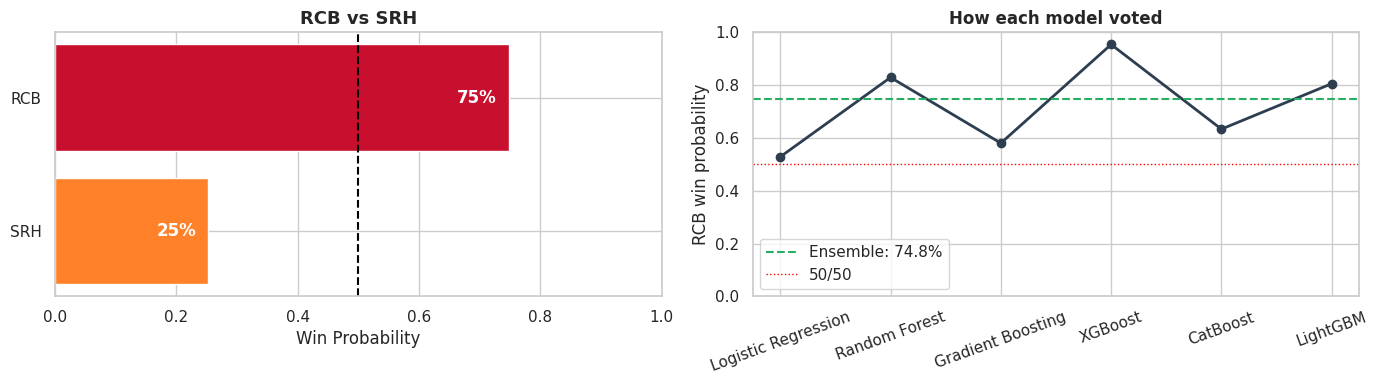

Predicted Winner: Royal Challengers Bengaluru

--- Eliminator: Gujarat Titans vs Rajasthan Royals ---


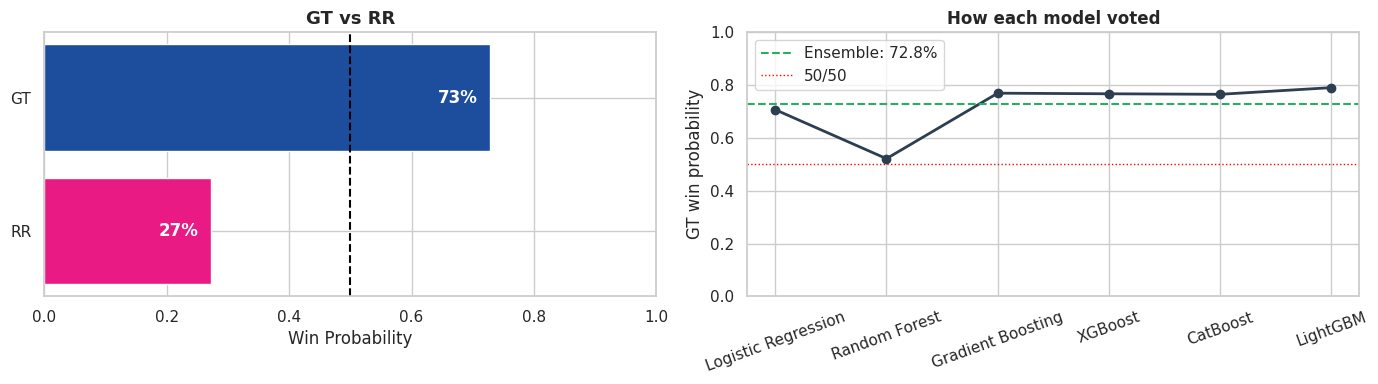

Predicted Winner: Gujarat Titans

--- Qualifier 2: Sunrisers Hyderabad vs Gujarat Titans ---


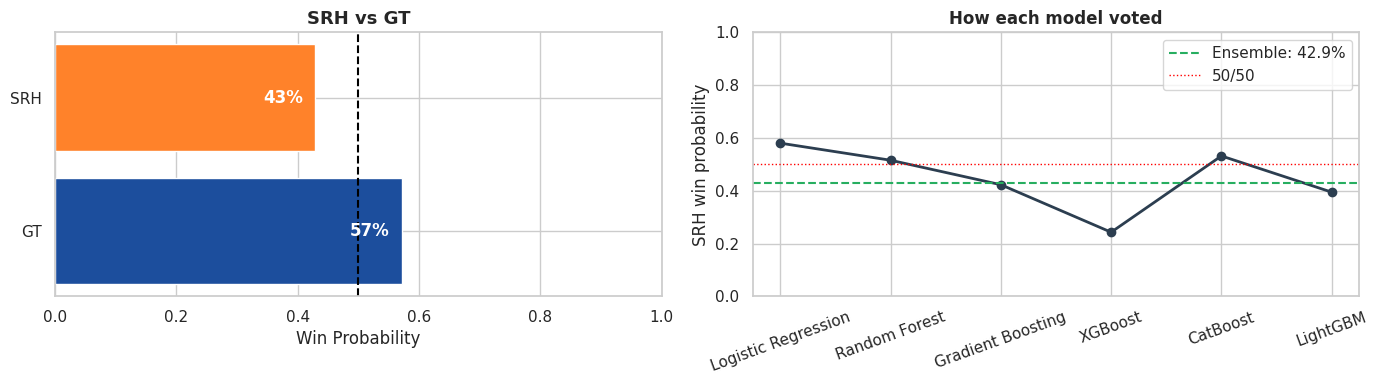

Predicted Winner: Gujarat Titans

--- FINAL: Royal Challengers Bengaluru vs Gujarat Titans ---


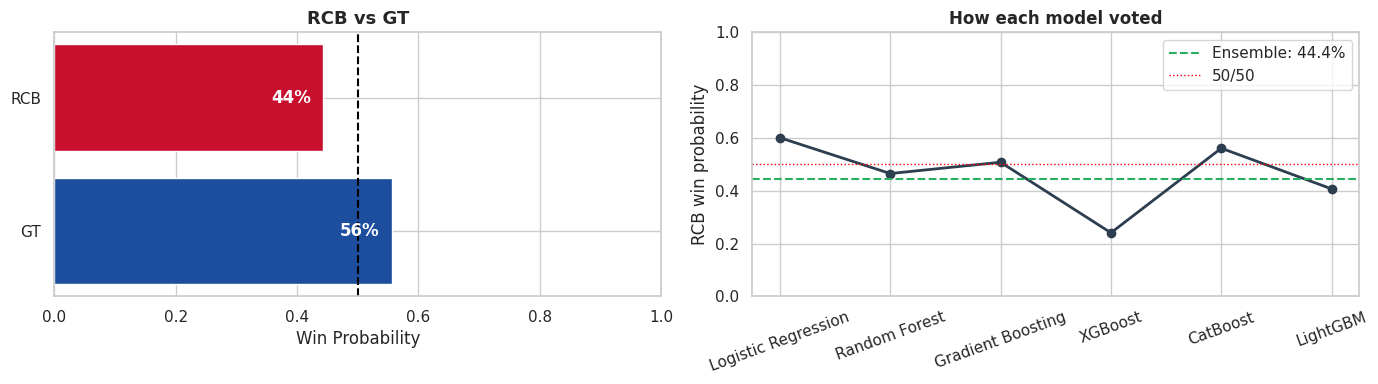

Predicted Champion: Gujarat Titans


In [ ]:
#top 4 from live table (exclude CSK if still excluded)
top4_candidates = points_table[points_table['team'] != 'Chennai Super Kings'] \
                    .sort_values('points', ascending=False).head(4)['team'].tolist()

# fallback if season hasn't started / not enough matches yet
if len(top4_candidates) < 4:
    top4_candidates = ['Royal Challengers Bengaluru', 'Gujarat Titans',
                       'Sunrisers Hyderabad', 'Rajasthan Royals']

t1, t2, t3, t4 = top4_candidates
print(f'\n🏆 Playoff top-4 (live): {[full_to_abbr.get(t, t) for t in top4_candidates]}')

# show individual playoff matchup predictions
final_venue = 'Narendra Modi Stadium, Ahmedabad'

print(f'\n--- Qualifier 1: {t1} vs {t2} ---')
show_prediction(t1, t2, final_venue)
p12, _ = predict_match(t1, t2, final_venue)
q1_winner = t1 if p12 > 0.5 else t2
q1_loser  = t2 if p12 > 0.5 else t1
print(f'Predicted Winner: {q1_winner}\n')

print(f'--- Eliminator: {t3} vs {t4} ---')
show_prediction(t3, t4, final_venue)
p34, _ = predict_match(t3, t4, final_venue)
elim_winner = t3 if p34 > 0.5 else t4
print(f'Predicted Winner: {elim_winner}\n')

print(f'--- Qualifier 2: {q1_loser} vs {elim_winner} ---')
show_prediction(q1_loser, elim_winner, final_venue)
pq2, _ = predict_match(q1_loser, elim_winner, final_venue)
q2_winner = q1_loser if pq2 > 0.5 else elim_winner
print(f'Predicted Winner: {q2_winner}\n')

print(f'--- FINAL: {q1_winner} vs {q2_winner} ---')
show_prediction(q1_winner, q2_winner, final_venue)
pfinal, _ = predict_match(q1_winner, q2_winner, final_venue)
champion_predicted = q1_winner if pfinal > 0.5 else q2_winner
print(f'Predicted Champion: {champion_predicted}')


In [ ]:
# 12. MONTE CARLO SIMULATION  (50,000 iterations — same as original)



Monte Carlo results (50,000 sims):
Team                                  Final%   Title%
Royal Challengers Bengaluru            85.9%    48.5%
Gujarat Titans                         41.6%    23.5%
Sunrisers Hyderabad                    59.5%    21.3%
Rajasthan Royals                       13.0%     6.8%


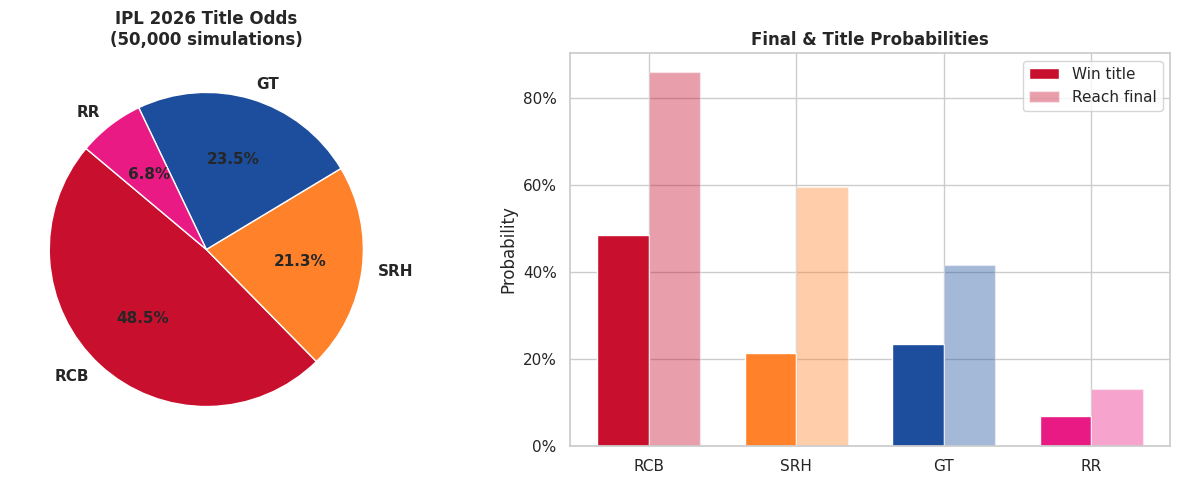

In [ ]:
n_sims = 50_000
np.random.seed(42)

matchup_probs = {}
for a in top4_candidates:
    for b in top4_candidates:
        if a != b:
            p, _ = predict_match(a, b, final_venue)
            matchup_probs[(a, b)] = p

champion_count = {t: 0 for t in top4_candidates}
finalist_count = {t: 0 for t in top4_candidates}

for _ in range(n_sims):
    rand = np.random.rand(4)
    q1w = t1 if rand[0] < matchup_probs[(t1, t2)] else t2
    q1l = t2 if rand[0] < matchup_probs[(t1, t2)] else t1
    ew  = t3 if rand[1] < matchup_probs[(t3, t4)] else t4
    q2w = q1l if rand[2] < matchup_probs[(q1l, ew)] else ew
    finalist_count[q1w] += 1
    finalist_count[q2w] += 1
    champ = q1w if rand[3] < matchup_probs[(q1w, q2w)] else q2w
    champion_count[champ] += 1

print(f'\nMonte Carlo results ({n_sims:,} sims):')
print(f'{"Team":<35} {"Final%":>8} {"Title%":>8}')
for t in sorted(top4_candidates, key=lambda t: -champion_count[t]):
    print(f'{t:<35} {finalist_count[t]/n_sims:>8.1%} {champion_count[t]/n_sims:>8.1%}')

team_abbr_colors = {full_to_abbr.get(t, t): team_colors.get(t, '#aaa') for t in top4_candidates}
champ_pcts = {full_to_abbr.get(t, t): champion_count[t] / n_sims for t in top4_candidates}
fin_pcts   = {full_to_abbr.get(t, t): finalist_count[t]  / n_sims for t in top4_candidates}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pie_colors = [team_abbr_colors.get(a, '#aaa') for a in champ_pcts]
axes[0].pie(champ_pcts.values(), labels=champ_pcts.keys(),
            autopct='%1.1f%%', startangle=140, colors=pie_colors,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title(f'IPL {CURRENT_SEASON} Title Odds\n({n_sims:,} simulations)',
                  fontweight='bold')
labels = list(champ_pcts.keys())
x, w  = np.arange(len(labels)), 0.35
bar_cols = [team_abbr_colors.get(a, '#aaa') for a in labels]
axes[1].bar(x - w/2, [champ_pcts[l] for l in labels], w, label='Win title',   color=bar_cols)
axes[1].bar(x + w/2, [fin_pcts[l]   for l in labels], w, label='Reach final', color=bar_cols, alpha=0.4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Probability')
axes[1].set_title('Final & Title Probabilities', fontweight='bold')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout()
plt.savefig('/content/viz_montecarlo.png', bbox_inches='tight')
plt.show()


In [ ]:

# export json to google drive(same as original)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════

all_matchups = []
for i, team_a in enumerate(current_teams):
    for team_b in current_teams[i+1:]:
        p, _ = predict_match(team_a, team_b, final_venue)
        all_matchups.append({
            'team_a': team_a, 'team_b': team_b,
            'abbr_a': full_to_abbr.get(team_a, team_a),
            'abbr_b': full_to_abbr.get(team_b, team_b),
            'prob_a': round(p, 4), 'prob_b': round(1 - p, 4)
        })

standings_out = []
for _, row in points_table.sort_values('points', ascending=False).iterrows():
    standings_out.append({
        'team':     row['team'],
        'abbr':     full_to_abbr.get(row['team'], row['team']),
        'color':    team_colors.get(row['team'], '#888'),
        'matches':  int(row['matches']),
        'wins':     int(row['wins']),
        'defeats':  int(row['defeats']),
        'points':   int(row['points']),
        'nrr':      float(row['nrr']),
        'strength': round(team_strength.get(row['team'], 5.0), 3)
    })

champion_odds_out = [
    {
        'team':         t,
        'abbr':         full_to_abbr.get(t, t),
        'color':        team_colors.get(t, '#888'),
        'champion_pct': round(champion_count[t] / n_sims, 4),
        'finalist_pct': round(finalist_count[t]  / n_sims, 4)
    }
    for t in sorted(top4_candidates, key=lambda t: -champion_count[t])
]

output = {
    'generated_at':  pd.Timestamp.now().isoformat(),
    'data_source':   'Cricsheet.org (live)',
    'season':        CURRENT_SEASON,
    'best_model':    best_model_name,
    'n_simulations': n_sims,
    'standings':     standings_out,
    'champion_odds': champion_odds_out,
    'matchups':      all_matchups
}

json_path = '/content/ipl2026_predictions.json'
with open(json_path, 'w') as f:
    json.dump(output, f, indent=2)

shutil.copy(json_path, base + '/ipl2026_predictions.json')
print(f'\n Saved to Google Drive → {base}/ipl2026_predictions.json')
print(f'   Matchups: {len(all_matchups)}  |  Standings: {len(standings_out)}')



 Saved to Google Drive → /content/drive/MyDrive/IPL Predictor/ipl2026_predictions.json
   Matchups: 45  |  Standings: 10


## 🎯 14. Custom Match Predictor — Edit & Re-run

In [ ]:
# 14. interactive
#     Change these variables and re-run this cell for a custom prediction


Available teams:
  PBKS — Punjab Kings
  RCB — Royal Challengers Bengaluru
  SRH — Sunrisers Hyderabad
  RR — Rajasthan Royals
  GT — Gujarat Titans
  CSK — Chennai Super Kings
  DC — Delhi Capitals
  KKR — Kolkata Knight Riders
  MI — Mumbai Indians
  LSG — Lucknow Super Giants

Venue examples (bias computed from live data):
  Maharashtra Cricket Association Stadium, Pune
  Subrata Roy Sahara Stadium
  Brabourne Stadium
  MA Chidambaram Stadium, Chepauk
  Himachal Pradesh Cricket Association Stadium
  Arun Jaitley Stadium, Delhi



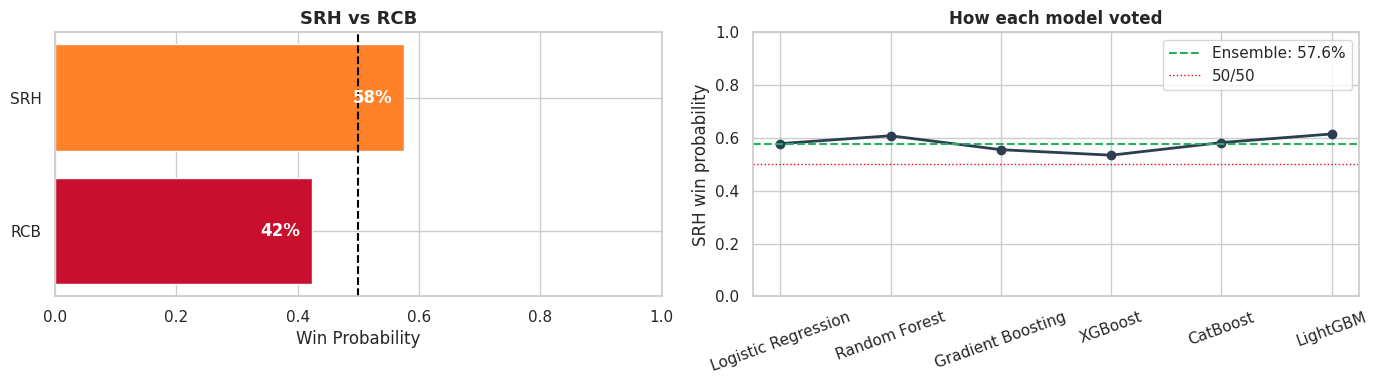

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════

team_a           = 'Sunrisers Hyderabad'
team_b           = 'Royal Challengers Bengaluru'
venue            = 'M. Chinnaswamy Stadium, Bengaluru'
team_a_won_toss  = True
toss_elected_bat = False

print('Available teams:')
for t in current_teams:
    print(f'  {full_to_abbr[t]} — {t}')

print('\nVenue examples (bias computed from live data):')
for v in list(venue_bias.keys())[:6]:
    print(f'  {v}')

print()
show_prediction(team_a, team_b, venue, team_a_won_toss, toss_elected_bat)
